In [30]:
# !pip install langchain-groq

In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langgraph.checkpoint.memory import MemorySaver

In [32]:
from google.colab import userdata
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

In [33]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY
)

In [34]:
class ChatState(TypedDict):

  messages: Annotated[list[BaseMessage], add_messages]

In [35]:
def chat_node(state: ChatState):

  messages = state['messages']
  response = model.invoke(messages)
  return {"messages": [response]}

In [36]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

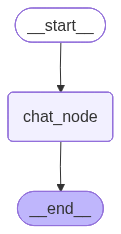

In [37]:
chatbot

In [38]:
initial_state = {
    "messages" : [HumanMessage(content="What is the capital of India")]
}

In [39]:
print(chatbot.invoke(initial_state)['messages'][-1].content)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [40]:
thread_id = "1"
while True:

  user_message = input("Type: ")
  print("user: ", user_message)
  if user_message.strip().lower() in ['exit','quit','bye']:
    break
  config = {"configurable":{"thread_id":thread_id}}
  response = chatbot.invoke({"messages":[HumanMessage(content=user_message)]}, config=config)
  print("AI: ", response['messages'][-1].content)

Type: hi
user:  hi
AI:  Hello! How can I help you today?
Type: my name is aryan
user:  my name is aryan
AI:  Nice to meet you, Aryan! How can I assist you today?
Type: what is my name
user:  what is my name
AI:  Your name is Aryan.
Type: exit
user:  exit


In [41]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='04480daf-bbc4-44e8-ab43-fa43cfb7c9ae'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi". Simple greeting. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.076114167, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.002628065, 'prompt_tokens_details': None, 'queue_time': 0.157728739, 'total_time': 0.078742232}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4727af4560', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6d65-0356-7a12-9cf7-c927a3dafadd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details':